# Poisson equation in a multi-patch domain

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import numpy as np
import scipy
import matplotlib.pyplot as plt
import itertools

np.set_printoptions(linewidth=100000)

from pyiga import bspline, assemble, vform, geometry, vis, solvers, topology, adaptive
from pyiga import assemble_cy, algebra_cy

In [2]:
# define discretization space (we may choose nested discretization spaces)
p = 3
N = 10
kvs = [2 * (bspline.make_knots(p, 0.0, 1.0, N),),
       2 * (bspline.make_knots(p, 0.0, 1.0, N),),
       2 * (bspline.make_knots(p, 0.0, 1.0, N),),
       2 * (bspline.make_knots(p, 0.0, 1.0, N),)]

In [3]:
# define geometry
geos = [
    geometry.quarter_annulus(),
    geometry.unit_square().translate((-1, 1)),
    geometry.quarter_annulus().rotate_2d(np.pi).translate((-1, 3)),
    geometry.quarter_annulus().rotate_2d(-np.pi/2).translate((-2, 1))
]

patches = [(kv, g) for kv,g in zip(kvs,geos)]

In [4]:
# source term f and Dirichlet boundary function g
f  = lambda x, y: np.exp(-5 * ((x-0.3)**2 + (y-1)**2))
gD = lambda x, y: 1e-1 * np.sin(8*x)

# Robin boundary data such that \partial_n u + alpha * u = g1, if alpha=0 this represents also a Neumann boundary condition.
gN = lambda x, y: 0.
alpha = lambda x, y: 0.

# set up a PatchMesh object, which detects interfaces between patches
M = topology.MultiPatch(patches)

# by default all outer boundaries are given the index 0, which we will exchange for the Dirichlet boundary
# and add another boundary for the Neumann/Robin boundary
M.set_boundary_id({'Neumann/Robin':{(0,'left'),(2,'right'),(3,'left'),(3,'right')},
                   'Dirichlet':{(0,'bottom'),(0,'right'),(1,'top'),(2,'bottom'),(2,'left'),(3,'bottom')}})

# set up a MultiPatch object that initializes a Basis to map global dofs to local dofs
MP = assemble.MultiBasis(M)
MP.set_subspace('C0')

# set Dirichlet values for DoFs at the Dirichlet boundary
dir_bcs = MP.set_fixed_boundary({'Dirichlet':gD})

# assemble the linear system and (possible) Neumann vector or Robin matrix/vector
Kh = MP.assemble_volume("inner(grad(u), grad(v)) * dx", arity = 2)
Fh = MP.assemble_volume("f * v * dx", arity=1, physical=True, f=f) #f is living in the physical domain

# generate Neumann vector for global contribution to the right hand side, in this case it is a zero vector since g1 is zero
Nh = MP.assemble_surface('(gN * v) * ds', arity=1, gN=gN, boundary_idx='Neumann/Robin')

# generate Robin Matrix for global contribution to the right hand side, in this case it is a zero matrix again since alpha is zero
Rh = MP.assemble_surface('(alpha * u * v) * ds', arity=2, alpha=alpha, boundary_idx='Neumann/Robin')

setting up constraints took 0.004496335983276367 seconds.
Basis setup took 0.0021457672119140625 seconds


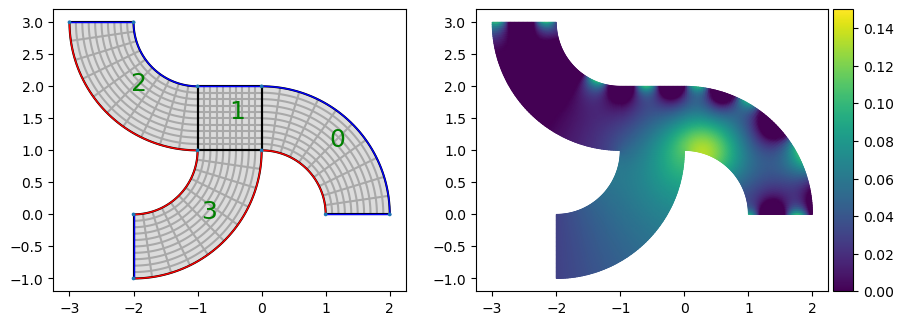

In [5]:
# set up and solve linear system by eliminating Dirichlet DoFs from the system
LS = assemble.RestrictedLinearSystem(Kh + Rh, Fh + Nh, dir_bcs)
u = LS.complete(solvers.make_solver(LS.A, spd=True)@LS.b)

# restrict solution to each individual patch (kvs on every patch) and visualize solution together with the mesh
fig, ax = plt.subplots(1,2,figsize=(10,5))
M.plotmesh(patch_idx = True, knots=True, nodes=True, bcolor={'Dirichlet':'blue','Neumann/Robin':'red'}, axis=ax[0])
MP.plot(u, range = (0, 1.5e-1),cbar=True, cmap='viridis', axis=ax[1], aspect='equal', cbar_width=0.2, cbar_pad = 0.05);
ax[0].axis('scaled'); #ax[1].axis('scaled');

# 

# Computerchip

In [6]:
# define geometry
def ComputerChip(p, N):
    geos = [
        geometry.Quad(np.array([[0,0.5,0.35, 0.5],[0,0,0.3,0.15]])),
        geometry.Quad(np.array([[0, 0.35, 0, 0.17],[0, 0.3, 0.6, 0.6]])),
        geometry.Quad(np.array([[0.35, 0.5, 0.17, 0.5],[0.3, 0.45, 0.6, 0.6]])),
        geometry.Quad(np.array([[0.17, 0.5, 0.17, 0.5],[0.6, 0.6, 0.8, 0.8]])),
        geometry.Quad(np.array([[0.5,1,0.5, 0.65],[0,0,0.15,0.3]])),
        geometry.Quad(np.array([[0.65, 1, 0.83, 1],[0.3,0,0.6,0.6]])),
        geometry.Quad(np.array([[0.5,0.65,0.5,0.83],[0.45,0.3,0.6,0.6]])),
        geometry.Quad(np.array([[0.5, 0.83, 0.5, 0.83],[0.6, 0.6, 0.8, 0.8]])),
    ]

    kvs = 8 * [2 * (bspline.make_knots(p, 0.0, 1.0, N),)]
    
    patches = [(kv, g) for kv,g in zip(kvs,geos)]
    M = topology.MultiPatch(patches)
    
    M.set_boundary_id({'Dirichlet':{(0,'top'),(2,'bottom'),(4,'top'),(6,'bottom')},
                       'Neumann':{(1,'top'),(1,'left'),(3,'top'),(3,'left'),(5,'top'),(5,'right'),(7,'top'),(7,'right')},
                       'Robin' : {(0,'bottom'),(4,'bottom')}})
    M.set_domain_id({0:{0,1,2,4,5,6}, 1:{3,7}})
    return M

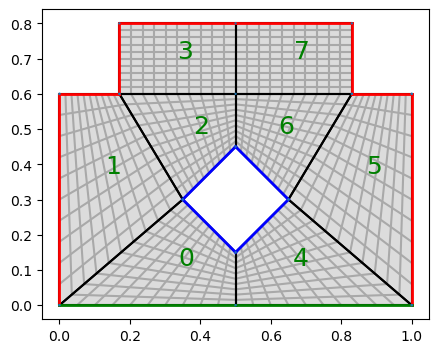

In [7]:
M = ComputerChip(3,10)

# visualize the PatchMesh object with Dirichlet boundary (blue) and Neumann boundary (red)
M.plotmesh(patch_idx = True, knots=True, nodes=True, bcolor={'Dirichlet':'blue','Neumann':'red','Robin':'green'}, bwidth=2)
plt.axis('scaled');

In [8]:
kappa = 130.0
alpha = 0.2
f = lambda x,y: 0.0
gN = lambda x,y: 0.0
gD = lambda x,y: 500.0
gR = lambda x,y: 300.0*alpha
lam = {0:0.01, 1:3.95}

In [9]:
MP = assemble.MultiBasis(M)
MP.set_subspace('C0')

# set Dirichlet values for DoFs at the Dirichlet boundary
dir_bcs = MP.set_fixed_boundary({'Dirichlet':gD})

# assemble the linear system and (possible) Neumann vector or Robin matrix/vector
Kh = sum([MP.assemble_volume("lam * inner(grad(u), grad(v)) * dx", arity = 2, domain_id=i, lam=lam[i]) for i in range(2)]) 
Fh = MP.assemble_volume("f * v * dx", arity=1, f=f) #f is living in the physical domain

# generate Neumann vector for global contribution to the right hand side, in this case it is a zero vector since g1 is zero
Nh = MP.assemble_surface('(gN * v) * ds', arity=1, gN=gN, boundary_idx='Neumann')

# generate Robin Matrix for global contribution to the right hand side, in this case it is a zero matrix again since alpha is zero
Rh = MP.assemble_surface('(alpha * u * v) * ds', arity=2, alpha=alpha, boundary_idx='Robin')
Nh += MP.assemble_surface('(gR * v) * ds', arity=1, gR=gR, boundary_idx='Robin')

setting up constraints took 0.029308795928955078 seconds.
Basis setup took 0.0042383670806884766 seconds


In [10]:
LS = assemble.RestrictedLinearSystem(Kh + Rh, Fh + Nh, dir_bcs)
u = LS.complete(solvers.make_solver(LS.A, spd=True)@LS.b)

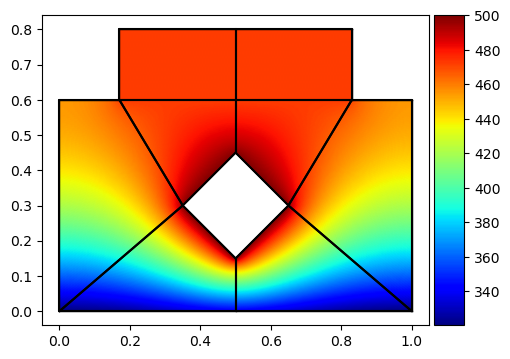

In [11]:
MP.plot(u, cbar=True, cmap='jet', aspect='equal', figsize=(5,5), physical=True, mesh=True);

# Using non-matching multi-patch domains for adaptive refinement

In [30]:
def solveChip(MP, lam, f):
    kappa = 130.0
    alpha = 0.2
    gN = lambda x,y: 0.0
    gD = lambda x,y: 500.0
    gR = lambda x,y: 300.0*alpha

    Kh = sum([MP.assemble_volume("lam * inner(grad(u), grad(v)) * dx", arity = 2, domain_id=i, lam=lam[i]) for i in range(len(lam))])
    Fh = sum([MP.assemble_volume("f * v * dx", arity=1, domain_id = i, f=f[i]) for i in range(2)]) #f is living in the physical domain
    Mh = sum([MP.assemble_volume("u * v * dx", arity=2, domain_id=i, in_subspace=False) for i in range(len(lam))])
    #lam_max = scipy.sparse.linalg.eigsh(Mh, k=1, which='LA', return_eigenvectors=False)[0]
    #lam_min = scipy.sparse.linalg.eigsh(Mh, k=1, which='SA', return_eigenvectors=False)[0]
    #print(lam_max/lam_min)

    #Phi = MP.Basis
    #lam_max = scipy.sparse.linalg.eigsh(Phi.T@Mh@Phi, k=1, which='LA', return_eigenvectors=False)[0]
    #lam_min = scipy.sparse.linalg.eigsh(Phi.T@Mh@Phi, k=1, which='SA', return_eigenvectors=False)[0]
    #print(lam_max/lam_min)
    

    Nh = MP.assemble_surface('(gN * v) * ds', arity=1, gN=gN, boundary_idx='Neumann')
    Rh = MP.assemble_surface('(alpha * u * v) * ds', arity=2, alpha=alpha, boundary_idx='Robin')
    Nh += MP.assemble_surface('(gR * v) * ds', arity=1, gR=gR, boundary_idx='Robin')

    LS = assemble.RestrictedLinearSystem(Kh + Rh, Fh + Nh, dir_bcs)
    return LS.complete(solvers.make_solver(LS.A, spd=True)@LS.b)

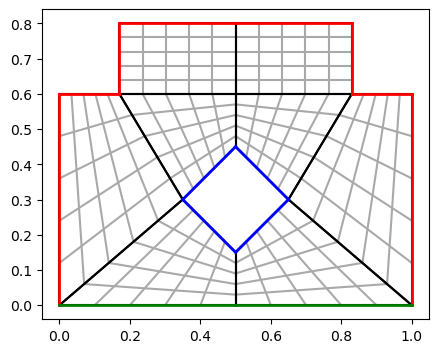

setting up constraints took 0.01168060302734375 seconds.
Basis setup took 0.0019228458404541016 seconds


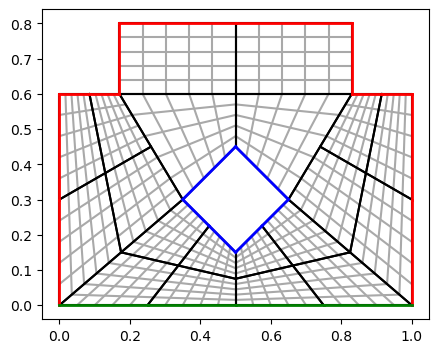

setting up constraints took 0.03753495216369629 seconds.
Basis setup took 0.0022280216217041016 seconds


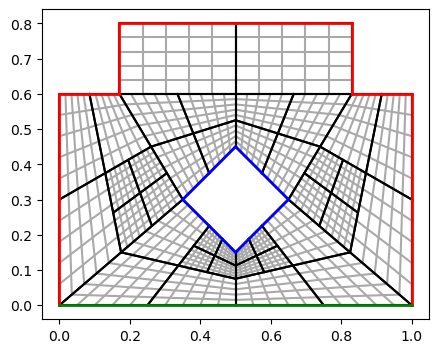

setting up constraints took 0.08643865585327148 seconds.
Basis setup took 0.002369403839111328 seconds


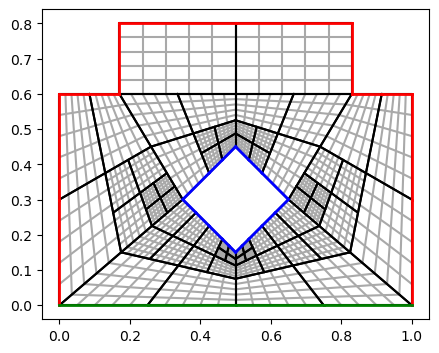

setting up constraints took 0.14581298828125 seconds.
Basis setup took 0.0033197402954101562 seconds


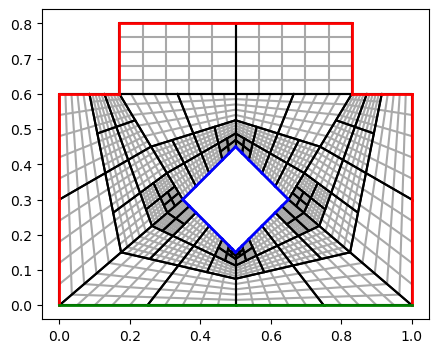

setting up constraints took 0.2315523624420166 seconds.
Basis setup took 0.0038177967071533203 seconds


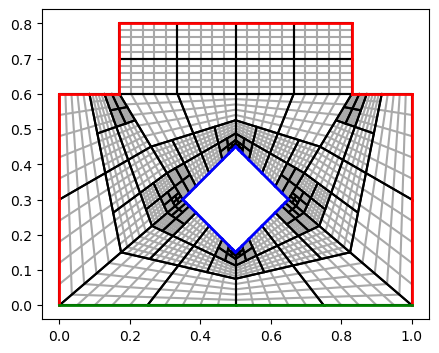

setting up constraints took 0.34006500244140625 seconds.
Basis setup took 0.00467228889465332 seconds


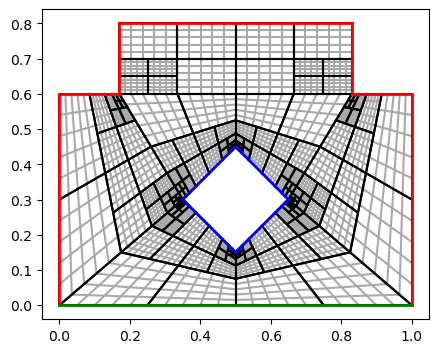

setting up constraints took 0.45263099670410156 seconds.
Basis setup took 0.0053331851959228516 seconds


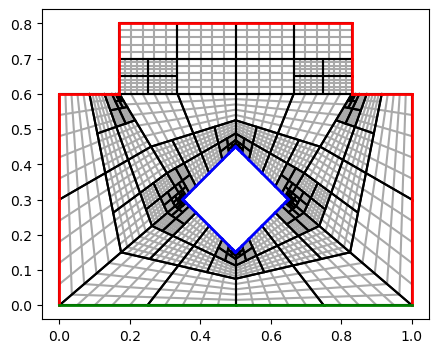

setting up constraints took 0.5472416877746582 seconds.
maxiter reached.
Basis setup took 0.00942850112915039 seconds


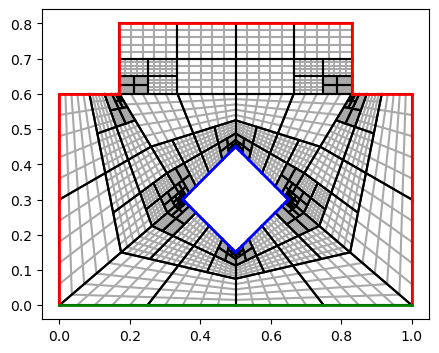

setting up constraints took 0.6581103801727295 seconds.
maxiter reached.
Basis setup took 0.010841846466064453 seconds


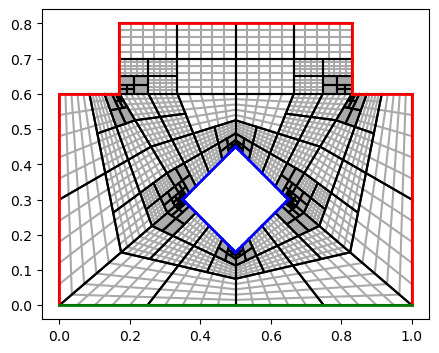

setting up constraints took 0.8130154609680176 seconds.
maxiter reached.
Basis setup took 0.0119476318359375 seconds


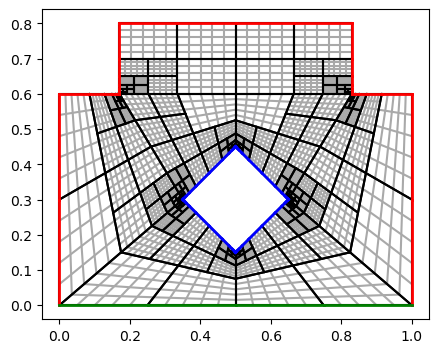

setting up constraints took 0.998100757598877 seconds.
maxiter reached.
Basis setup took 0.01388239860534668 seconds


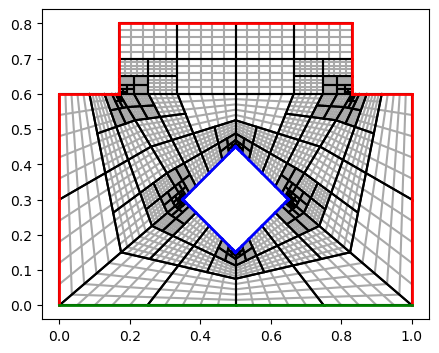

setting up constraints took 1.187161922454834 seconds.
Basis setup took 0.010234355926513672 seconds


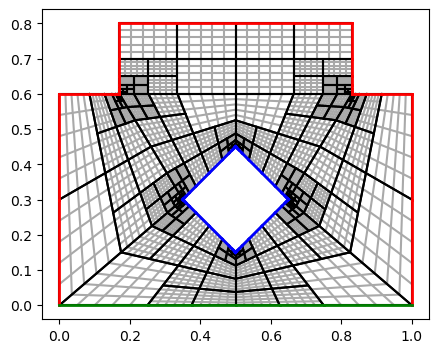

setting up constraints took 1.5508348941802979 seconds.
Basis setup took 0.012476444244384766 seconds


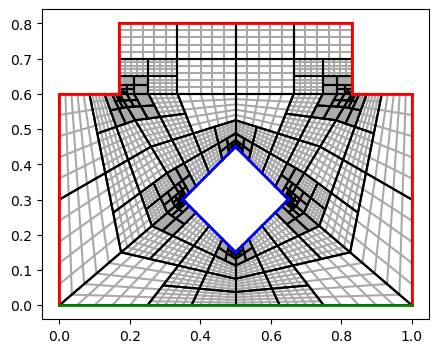

setting up constraints took 2.1518890857696533 seconds.
Basis setup took 0.01733875274658203 seconds


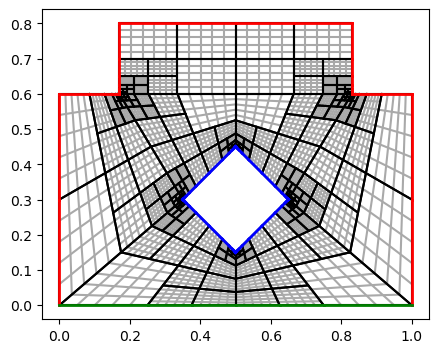

setting up constraints took 3.2943215370178223 seconds.
Basis setup took 0.026116609573364258 seconds


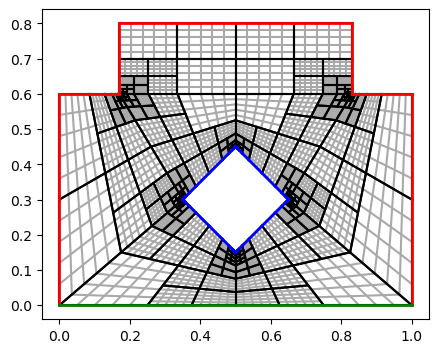

setting up constraints took 5.04489541053772 seconds.
Basis setup took 0.03880572319030762 seconds
Iteration hit maximal number of iterations (15).


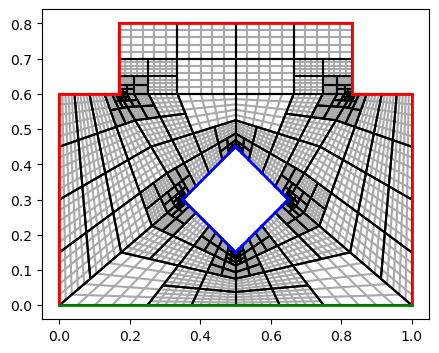

setting up constraints took 8.32479476928711 seconds.
Basis setup took 0.06593036651611328 seconds


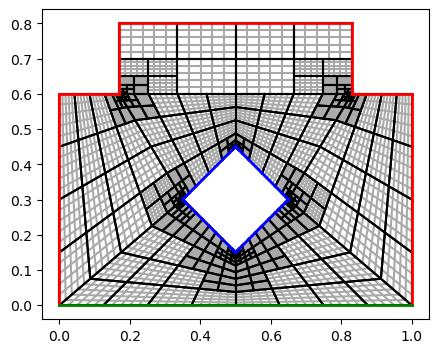

setting up constraints took 13.964079141616821 seconds.
Basis setup took 0.11606478691101074 seconds


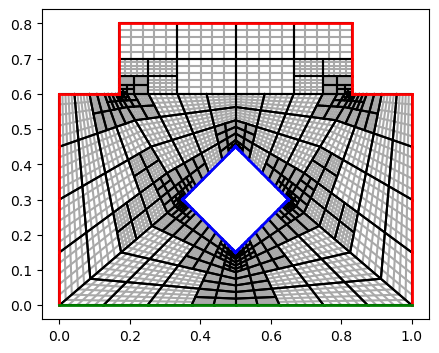

setting up constraints took 24.208983898162842 seconds.
Basis setup took 0.23972344398498535 seconds


In [ ]:
M = ComputerChip(3,5)

maxiter=15
it=0
lam = {0:3.95, 1:3.95}
f = {0:0., 1:0.}
while True:
    M.plotmesh(figsize=(5,5),patch_idx = False, knots=True, nodes=False, color='white', 
               bcolor={'Dirichlet':'blue','Neumann':'red','Robin':'green'}, bwidth=2)
    plt.axis('scaled');
    plt.show()

    MP = assemble.MultiBasis(M)
    MP.set_subspace('C0')

    Phi = MP.Basis
    lam_max = scipy.sparse.linalg.eigsh(Phi.T@Phi, k=1, which='LA', return_eigenvectors=False)[0]
    lam_min = scipy.sparse.linalg.eigsh(Phi.T@Phi, k=1, which='SA', return_eigenvectors=False)[0]
    #print(lam_max,lam_min)

    dir_bcs = MP.set_fixed_boundary({'Dirichlet':gD})

    #assemble and solve
    u = solveChip(MP, lam, f)

    #estimate
    err_ind = adaptive.mp_resPois(MP,u,a=lam, f=f)
    eta=np.linalg.norm(err_ind)
    #print(eta)
    if eta < 1e-4:
        print("#############################################################")
        print("Terminated successfully after {} iterations".format(it))
        print("#############################################################")
        break
    if it==maxiter:
        print("Iteration hit maximal number of iterations ({}).".format(maxiter))

    #mark
    marked_patches = adaptive.doerfler_mark(err_ind, theta=0.95, TOL=0.05)

    #refine
    M.h_refine(patches=marked_patches,ref="rs");
    it+=1
    
MP.plot(u, cbar=True, cmap='jet', aspect='equal', figsize=(5,5), physical=True);

In [ ]:
for ((p1,bd1,s1),(p2,bd2,s2), flip) in MP.intfs:
    print(p1,p2)
    MP.compute_C0_constraint(p1, bd1, s1, p2, bd2, s2, flip)

In [15]:
MP.mesh.interfaces

{(0, 2, 0): ((1, 0, 0), (False,)),
 (1, 0, 0): ((0, 2, 0), (False,)),
 (4, 2, 0): ((11, 3, 0), (False,)),
 (2, 2, 0): ((29, 3, 0), (False,)),
 (3, 0, 0): ((36, 1, 0), (False,)),
 (6, 2, 0): ((35, 3, 0), (False,)),
 (3, 3, 0): ((7, 2, 0), (False,)),
 (7, 2, 0): ((3, 3, 0), (False,)),
 (5, 0, 0): ((10, 3, 1), (True,)),
 (5, 2, 0): ((32, 3, 0), (False,)),
 (7, 0, 0): ((33, 1, 0), (False,)),
 (8, 3, 0): ((17, 0, np.int64(0)), (True,)),
 (np.int32(4), 3, 0): ((8, 2, 0), (False,)),
 (8, 2, 0): ((np.int32(4), 3, 0), (False,)),
 (np.int32(4), 1, 0): ((9, 0, 0), (False,)),
 (9, 0, 0): ((np.int32(4), 1, 0), (False,)),
 (9, 2, 0): ((20, 3, 0), (False,)),
 (8, 1, 0): ((10, 0, 0), (False,)),
 (10, 0, 0): ((8, 1, 0), (False,)),
 (10, 2, np.int64(0)): ((23, 3, 0), (False,)),
 (10, 3, 0): ((26, 0, 0), (True,)),
 (11, 3, 0): ((4, 2, 0), (False,)),
 (np.int32(0), 3, 0): ((11, 2, 0), (False,)),
 (11, 2, 0): ((np.int32(0), 3, 0), (False,)),
 (np.int32(0), 1, 0): ((12, 0, 0), (False,)),
 (12, 0, 0): ((np.i

In [16]:
intfs=set()
for ((p1,bd1,s1),((p2,bd2,s2),flip)) in MP.mesh.interfaces.items():
    if (p1==10 and p2==26) or (p1==26 and p2==10):
        if (((p1,bd1,s1),(p2,bd2,s2),flip) not in intfs) and (((p2,bd2,s2),(p1,bd1,s1),flip) not in intfs):
            if assemble.boundary_kv(MP.mesh.kvs[p1],bd1) <= assemble.boundary_kv(MP.mesh.kvs[p2],bd2):
                intfs.add(((p1,bd2,s2),(p1,bd1,s1),flip))
            elif assemble.boundary_kv(MP.mesh.kvs[p1],bd1) > assemble.boundary_kv(MP.mesh.kvs[p2],bd2):
                intfs.add(((p1,bd1,s1),(p2,bd2,s2),flip))
            print(p1,p2)
    

10 26


In [19]:
assemble.boundary_kv(MP.mesh.kvs[10],3)

(KnotVector(array([0.5, 0.5, 0.5, 0.5, 0.6, 0.7, 0.8, 0.9, 1. , 1. , 1. , 1. ]), 3),)

In [23]:
assemble.boundary_kv(MP.mesh.kvs[26],0,flip=(True,))

(KnotVector(array([0.5 , 0.5 , 0.5 , 0.5 , 0.55, 0.6 , 0.65, 0.7 , 0.75, 0.75, 0.75, 0.75]), 3),)

In [21]:
assemble.boundary_kv

<function pyiga.assemble.boundary_kv(kvs, bdspec, swap=None, flip=None)>

In [17]:
intfs

{((10, 3, 0), (26, 0, 0), (True,))}

In [18]:
MP.intfs

{((np.int32(0), 1, 0), (12, 0, 0), (False,)),
 ((0, 2, 0), (1, 0, 0), (False,)),
 ((np.int32(0), 3, 0), (11, 2, 0), (False,)),
 ((np.int32(1), 1, 0), (15, 0, 0), (False,)),
 ((np.int32(1), 3, 0), (14, 2, 0), (False,)),
 ((np.int32(1), 3, 1), (30, 2, 0), (False,)),
 ((np.int32(2), 1, 0), (36, 0, 0), (False,)),
 ((2, 2, 0), (29, 3, 0), (False,)),
 ((2, 2, 1), (31, 3, 0), (False,)),
 ((np.int32(2), 3, 0), (35, 2, 0), (False,)),
 ((3, 0, 0), (36, 1, 0), (False,)),
 ((3, 0, 1), (37, 1, 0), (False,)),
 ((3, 3, 0), (7, 2, 0), (False,)),
 ((np.int32(4), 1, 0), (9, 0, 0), (False,)),
 ((np.int32(4), 1, 1), (23, 0, 0), (False,)),
 ((4, 2, 0), (11, 3, 0), (False,)),
 ((np.int32(4), 3, 0), (8, 2, 0), (False,)),
 ((np.int32(5), 1, 0), (27, 0, 0), (False,)),
 ((np.int32(5), 3, 0), (26, 2, 0), (False,)),
 ((np.int32(6), 1, 0), (33, 0, 0), (False,)),
 ((6, 2, 0), (35, 3, 0), (False,)),
 ((np.int32(6), 3, 0), (32, 2, 0), (False,)),
 ((7, 0, 0), (33, 1, 0), (False,)),
 ((7, 0, 1), (34, 1, 0), (False,)),


In [26]:
MP.compute_C0_constraint(10,3,0,26,0,0,(True,))

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 28 stored elements and shape (8, 2432)>

In [14]:
from scipy.sparse.linalg import norm as spnorm

print(spnorm(MP.B@MP.Basis))

3.082207001485552


In [25]:
(MP.B@MP.Basis).data

array([-3.46944695e-18, -5.55111512e-17, -3.46944695e-18,  3.46944695e-18, -3.46944695e-18, -5.55111512e-17, -3.46944695e-18, -3.46944695e-18, -3.46944695e-18, -3.46944695e-18,  1.01608257e-14, -5.00000000e-01, -5.00000000e-01,  1.00000000e+00, -3.46944695e-18, -5.55111512e-17, -3.46944695e-18, -3.46944695e-18, -5.55111512e-17, -3.46944695e-18, -3.46944695e-18,  3.46944695e-18, -3.46944695e-18, -3.46944695e-18, -3.46944695e-18,  3.46944695e-18,  3.46944695e-18, -3.46944695e-18,  1.00000000e+00,  2.83375753e-14, -1.45483408e-13,  3.83172660e-13, -7.11708470e-13, -1.00000000e+00,  3.20740643e-12,  1.00000000e+00,  3.59447320e-14, -1.41687877e-13,  7.27417041e-13, -1.91585636e-12, -1.00000000e+00,  4.23321877e-12, -1.48866965e-12,  1.00000000e+00,  2.70688301e-14, -1.15023143e-13,  4.53401205e-13, -2.32773453e-12, -1.00000000e+00,  2.17507046e-12, -1.13527231e-12,  3.99234134e-13,  1.00000000e+00, -9.98163109e-14,  4.24147838e-13, -1.67188485e-12, -1.00000000e+00,  1.33754119e-12, -5.8984

In [16]:
MP.Basis

<Compressed Sparse Column sparse matrix of dtype 'float64'
	with 49983 stored elements and shape (41216, 30938)>

In [17]:
MP.P2G@MP.Basis-

SyntaxError: invalid syntax (2742522587.py, line 1)

In [18]:
spnorm(MP.P2G@MP.Basis-scipy.sparse.identity(MP.Basis.shape[1]))# <1e-12*np.sqrt(self.Basis.shape[1])

np.float64(0.0)

In [19]:
1e-12*np.sqrt(MP.Basis.shape[1])

np.float64(1.7589201232574489e-10)

In [20]:
spnorm

<function scipy.sparse.linalg._norm.norm(x, ord=None, axis=None)>

In [21]:
print(spnorm(MP.B@MP.Basis))

3.082207001485552


In [22]:
1e-12*spnorm(MP.B)*spnorm(MP.Basis)

np.float64(2.7676072172145152e-08)

In [23]:
abs(MP.B.data).min()

np.float64(1.000546019197917e-14)